# 비정형 이미지 데이터 수집 (여러 ZIP)

`dataset/비정형/` 폴더에 있는 **여러 개의 ZIP 아카이브**를 순회하면서, 내부의 이미지 파일 경로를 수집하고 필요 시 메모리에서 열어 확인하는 흐름을 보여줍니다.

- **표준 라이브러리**: `pathlib`, `zipfile`, `io`
- **이미지 표시**: `Pillow` + `matplotlib`

> 노트북 위치: `소집교육/0424/` 기준 상대 경로 `../dataset/비정형/` 을 사용합니다.

In [1]:
# ── 정형 데이터 폴더 경로 ──────────────────────────────────────────────────
# 저장소 루트·0423 등 cwd에 따라 `dataset/정형`을 찾습니다.

import io
import zipfile
from pathlib import Path


def resolve_unstructured_images_dir() -> Path:
    """저장소 루트 또는 `0424`에서 실행해도 `dataset/비정형`을 찾습니다."""
    cwd = Path.cwd()
    candidates = [
        cwd / "소집교육" / "dataset" / "비정형",
        cwd / "dataset" / "비정형",
        cwd.parent / "dataset" / "비정형",  # cwd가 .../소집교육/0424 일 때
    ]
    for c in candidates:
        if c.is_dir():
            return c.resolve()
    raise FileNotFoundError(
        "dataset/비정형 폴더를 찾을 수 없습니다. 노트북 cwd를 프로젝트 루트 또는 소집교육/0424로 맞춰 주세요."
    )


UNSTRUCTURED_DIR = resolve_unstructured_images_dir()
print("비정형 폴더:", UNSTRUCTURED_DIR)


비정형 폴더: C:\2026\mli_dev_2026\소집교육\dataset\비정형


## 한글 폰트 (Matplotlib)

`try` / `except`로 폰트를 순서대로 시도합니다.

- **Windows 기본**: `Malgun Gothic` (맑은 고딕)
- **macOS 기본**: `Apple SD Gothic Neo` → `AppleGothic`
- **기타(Linux 등)**: `NanumGothic`, `Noto Sans CJK KR` 순

In [2]:
# ── Matplotlib ────────────────────────────────────────────────────
# 그래프·축·스타일

import platform

import matplotlib.pyplot as plt
from matplotlib import font_manager

def setup_matplotlib_korean_font() -> str | None:
    """Windows / Mac / 기타 순으로 한글 폰트를 try-except로 적용."""
    try:
        plt.rcParams["axes.unicode_minus"] = False
    except Exception:
        pass

    system = platform.system()

    if system == "Windows":
        candidates = ["Malgun Gothic", "맑은 고딕"]
    elif system == "Darwin":
        candidates = ["Apple SD Gothic Neo", "AppleGothic"]
    else:
        candidates = ["NanumGothic", "Noto Sans CJK KR", "Malgun Gothic"]

    for family in candidates:
        try:
            prop = font_manager.FontProperties(family=family)
            path = font_manager.findfont(prop, fallback_to_default=False)
            if path and "dejavu" not in path.lower():
                plt.rcParams["font.family"] = family
                print(f"[한글 폰트] 적용: {family}")
                return family
        except Exception as exc:
            print(f"[한글 폰트] 후보 실패 ({family}): {exc}")
            continue

    # 검증 없이 플랫폼 기본 이름만 지정 (실제 글리프는 런타임에 확인)
    try:
        if system == "Windows":
            plt.rcParams["font.family"] = "Malgun Gothic"
            print("[한글 폰트] 폴백(Windows): Malgun Gothic")
            return "Malgun Gothic"
        if system == "Darwin":
            plt.rcParams["font.family"] = "Apple SD Gothic Neo"
            print("[한글 폰트] 폴백(macOS): Apple SD Gothic Neo")
            return "Apple SD Gothic Neo"
    except Exception as exc:
        print(f"[한글 폰트] 폴백 실패: {exc}")

    print("[한글 폰트] 시스템 기본만 사용 — 한글이 깨질 수 있습니다.")
    return None

setup_matplotlib_korean_font()


[한글 폰트] 적용: Malgun Gothic


'Malgun Gothic'

## 1. 비정형 폴더의 ZIP 목록

`*.zip` 파일을 모아 각 아카이브 이름과 경로를 확인합니다.

In [3]:
# ── 구조화 dtype ─────────────────────────────────────────────────────
# 필드명이 있는 복합 dtype

zip_paths = sorted(UNSTRUCTURED_DIR.glob("*.zip"))
for i, zp in enumerate(zip_paths, 1):
    print(f"{i}. {zp.name}  ({zp.stat().st_size / 1e6:.1f} MB)")
print(f"\n총 {len(zip_paths)}개 ZIP")


1. 드론항공데이터셋.zip  (1254.5 MB)
2. 무기류탐지데이터셋.zip  (440.1 MB)
3. 불법소지품탐지데이터셋.zip  (988.5 MB)

총 3개 ZIP


## 2. 각 ZIP 내부에서 이미지 경로만 수집

`zipfile.ZipFile`으로 열고 `namelist()` 또는 `infolist()`로 멤버를 순회합니다.  
디렉터리 항목과 비이미지 파일은 제외합니다.

In [4]:
# ── 함수 정의 ─────────────────────────────────────────────────────────
# 재사용 가능한 블록

IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".gif", ".tif", ".tiff"}

def iter_image_members(zip_path: Path):
    """ZIP 안의 (회원 이름, ZipInfo) 중 이미지 확장자만 반환."""
    with zipfile.ZipFile(zip_path, mode="r") as zf:
        for info in zf.infolist():
            if info.is_dir():
                continue
            suffix = Path(info.filename).suffix.lower()
            if suffix in IMAGE_SUFFIXES:
                yield info.filename, info


def collect_image_index(zip_paths: list[Path]) -> list[dict]:
    """모든 ZIP에서 이미지 목록을 한 리스트로 모읍니다."""
    rows: list[dict] = []
    for zp in zip_paths:
        with zipfile.ZipFile(zp, mode="r") as zf:
            for info in zf.infolist():
                if info.is_dir():
                    continue
                if Path(info.filename).suffix.lower() not in IMAGE_SUFFIXES:
                    continue
                rows.append(
                    {
                        "zip_file": zp.name,
                        "zip_path": str(zp),
                        "member": info.filename,
                        "size_bytes": info.file_size,
                    }
                )
    return rows


image_index = collect_image_index(zip_paths)
print(f"수집된 이미지 항목 수: {len(image_index):,}")
if image_index:
    print("예시 3건:", image_index[:3])


수집된 이미지 항목 수: 58,225
예시 3건: [{'zip_file': '드론항공데이터셋.zip', 'zip_path': 'C:\\2026\\mli_dev_2026\\소집교육\\dataset\\비정형\\드론항공데이터셋.zip', 'member': 'test/images/0-2022-12-11-14h14m55s799_jpg.rf.8b3448a85f4efd98076f73a66ccadcc6.jpg', 'size_bytes': 13729}, {'zip_file': '드론항공데이터셋.zip', 'zip_path': 'C:\\2026\\mli_dev_2026\\소집교육\\dataset\\비정형\\드론항공데이터셋.zip', 'member': 'test/images/0-2022-12-11-14h15m03s489_jpg.rf.90f718d25034f371b96a44f9e748a6cc.jpg', 'size_bytes': 18055}, {'zip_file': '드론항공데이터셋.zip', 'zip_path': 'C:\\2026\\mli_dev_2026\\소집교육\\dataset\\비정형\\드론항공데이터셋.zip', 'member': 'test/images/0-2022-12-11-14h15m06s454_jpg.rf.d694364e5bfc7dc20e6c0b9080948a64.jpg', 'size_bytes': 14636}]


## 3. ZIP별 이미지 개수 요약

수집 결과를 `pandas`로 집계하면 데이터셋 규모를 한눈에 볼 수 있습니다.

In [5]:
# ── groupby 집계 ────────────────────────────────────────────────────
# 범주별 요약·변환

import pandas as pd

df_img = pd.DataFrame(image_index)
if not df_img.empty:
    summary = (
        df_img.groupby("zip_file", as_index=False)
        .agg(image_count=("member", "count"), total_mb=("size_bytes", lambda s: s.sum() / 1e6))
        .sort_values("image_count", ascending=False)
    )
    display(summary)
else:
    print("이미지가 없습니다. ZIP 경로를 확인하세요.")


,zip_file,image_count,total_mb
0,드론항공데이터셋.zip,30712,1238.287697
2,불법소지품탐지데이터셋.zip,17501,1005.440463
1,무기류탐지데이터셋.zip,10012,434.396043


## 4. 디스크에 풀지 않고 ZIP에서 이미지 읽기

`ZipFile.read(member)` → `BytesIO` → `PIL.Image.open` 으로 메모리에서 바로 엽니다.  
(대용량일 때는 샘플만 열도록 제한하는 것이 좋습니다.)

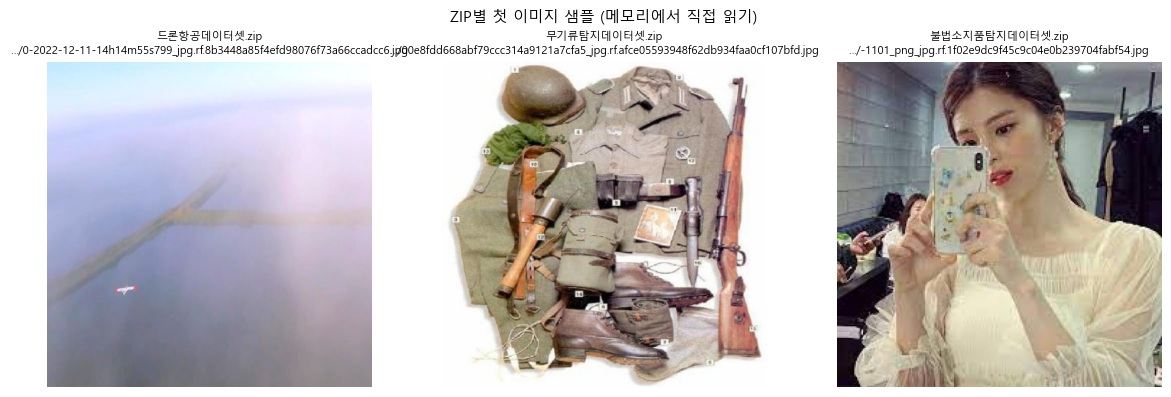

In [6]:
# ── Matplotlib ────────────────────────────────────────────────────
# 그래프·축·스타일

from PIL import Image
import matplotlib.pyplot as plt


def load_image_from_zip(zip_path: Path, member: str) -> Image.Image:
    with zipfile.ZipFile(zip_path, mode="r") as zf:
        data = zf.read(member)
    return Image.open(io.BytesIO(data)).convert("RGB")


# 각 ZIP에서 첫 이미지 1장씩만 미리보기 (압축 해제 없이)
n_preview = min(3, len(zip_paths))
if n_preview == 0:
    print("ZIP이 없어 미리보기를 건너뜁니다.")
else:
    fig, axes = plt.subplots(1, n_preview, figsize=(4 * n_preview, 4))
    if n_preview == 1:
        axes = [axes]
    for ax, zp in zip(axes, zip_paths[:n_preview]):
        first = next(iter_image_members(zp), None)
        if first is None:
            ax.set_title(f"{zp.name}\n(이미지 없음)")
            ax.axis("off")
            continue
        member, _ = first
        im = load_image_from_zip(zp, member)
        ax.imshow(im)
        ax.set_title(f"{zp.name}\n…/{Path(member).name}", fontsize=8)
        ax.axis("off")
    plt.suptitle("ZIP별 첫 이미지 샘플 (메모리에서 직접 읽기)", fontsize=11)
    plt.tight_layout()
    plt.show()


## 4-1. ZIP별 샘플 이미지 단순 분석과 지표 의미

각 ZIP에서 **대표 이미지 1장**을 꺼내 아래를 계산합니다.

| 지표 | 의미 |
|------|------|
| **해상도 (가로×세로)** | 모델 입력 크기·메모리·추론 시간과 직결. 서로 다른 해상도가 섞이면 전처리(리사이즈) 필요. |
| **종횡비** | 1에 가까우면 정사각형에 가깝고, 크면 가로/세로로 긴 이미지(촬영 각도·도메인 편향 점검). |
| **채널 평균 (R,G,B)** | 전체 색조·밝기 경향(야간/실내/하늘 비율 등). 데이터셋 간 분포 차이 시 도메인 갭 신호. |
| **밝기(휘도 근사)** | `(0.299R+0.587G+0.114B)` 평균. 너무 어둡거나 밝으면 노출·라벨링 난이도 점검. |
| **대비(채널 표준편차 평균)** | 낮으면 흐릿·평탄한 영상, 높으면 경계·질감이 뚜렷(탐지 과제에서 특징 추출 난이도와 연관). |

> 본 분석은 **라이브러리 없이 가능한 기초 통계**이며, 객체 탐지 품질은 별도 라벨·모델 평가가 필요합니다.

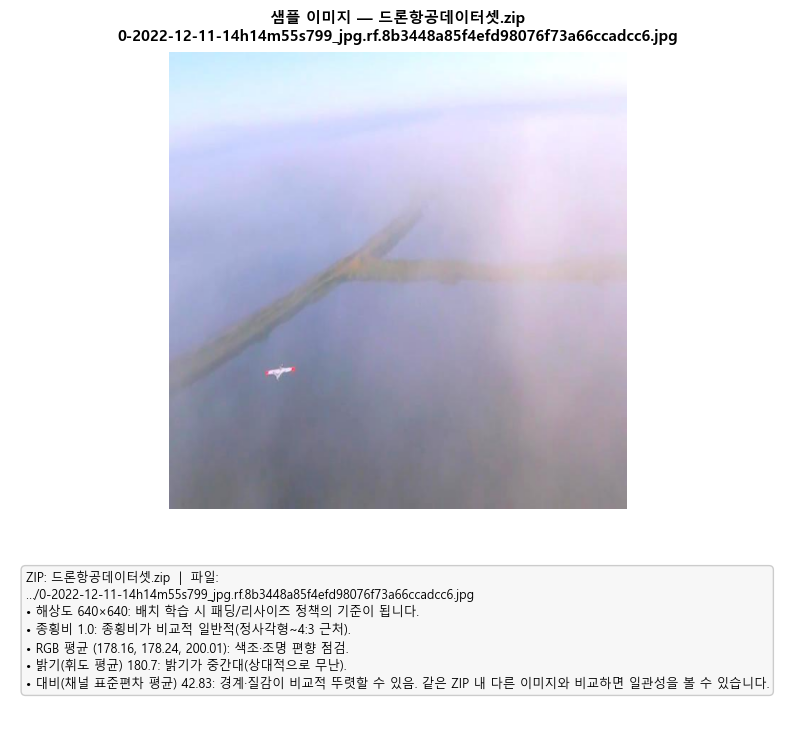

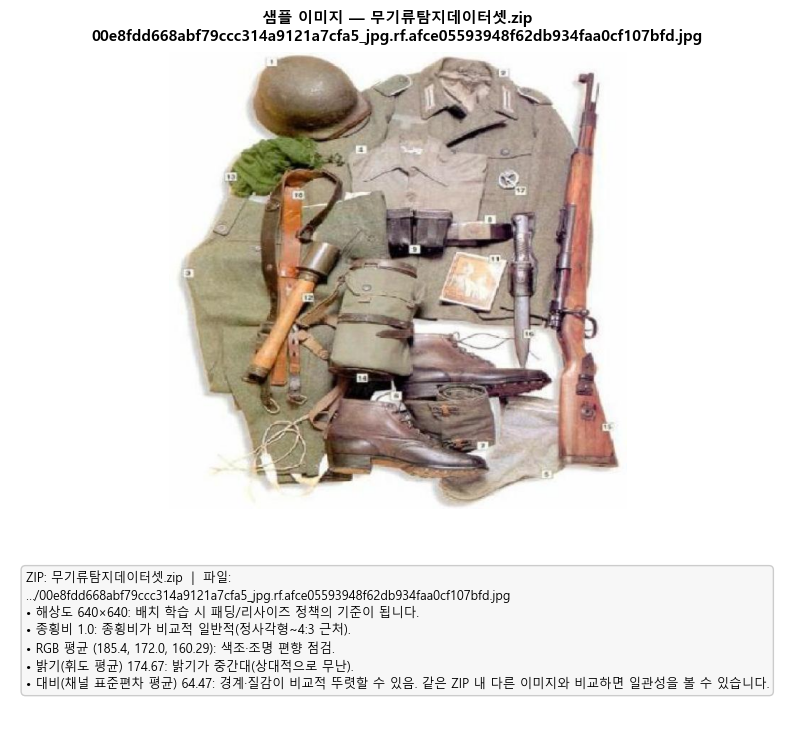

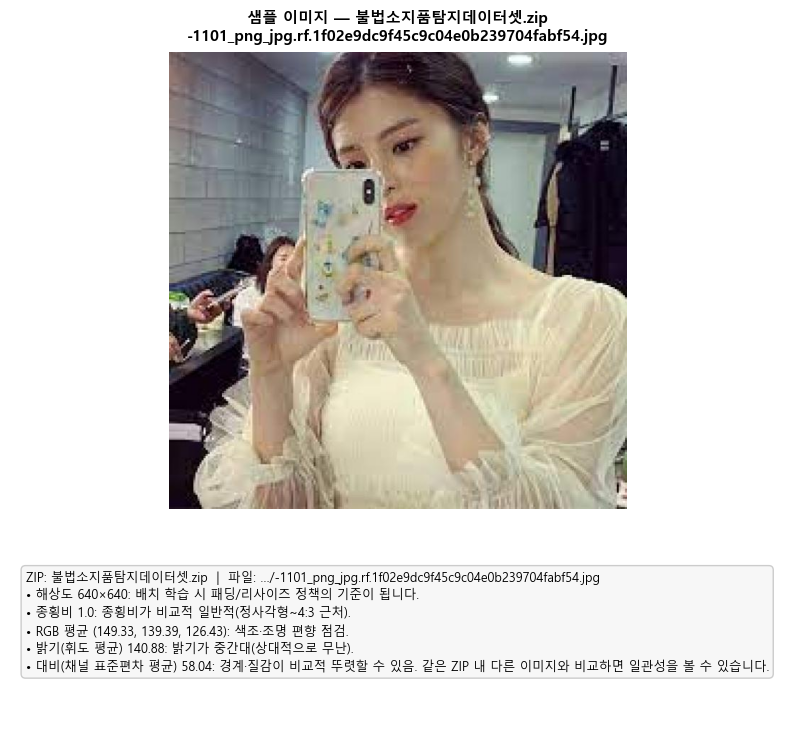

,zip_file,member_tail,width,height,aspect_ratio,mean_R,mean_G,mean_B,brightness,contrast_rgb
0,드론항공데이터셋.zip,0-2022-12-11-14h14m55s799_jpg.rf.8b3448a85f4ef...,640,640,1.0,178.16,178.24,200.01,180.70,42.83
1,무기류탐지데이터셋.zip,00e8fdd668abf79ccc314a9121a7cfa5_jpg.rf.afce05...,640,640,1.0,185.40,172.00,160.29,174.67,64.47
2,불법소지품탐지데이터셋.zip,-1101_png_jpg.rf.1f02e9dc9f45c9c04e0b239704fab...,640,640,1.0,149.33,139.39,126.43,140.88,58.04



[요약] 위 표는 ZIP별 '첫 이미지'만의 스냅샷입니다. 실제 EDA는 무작위 샘플링·히스토그램·학습/검증 분할별 비교를 권장합니다.


In [7]:
# ── Matplotlib ────────────────────────────────────────────────────
# 그래프·축·스타일

import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def analyze_image_basic(img: Image.Image) -> dict:
    """PIL 이미지에 대한 단순 수치 특성 (도메인/품질 1차 점검용)."""
    rgb = img.convert("RGB")
    arr = np.asarray(rgb, dtype=np.float64)
    h, w, _ = arr.shape
    r, g, b = arr[:, :, 0], arr[:, :, 1], arr[:, :, 2]
    # ITU-R BT.601 luma 근사
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    return {
        "width": int(w),
        "height": int(h),
        "aspect_ratio": round(w / h, 4),
        "mean_R": round(float(r.mean()), 2),
        "mean_G": round(float(g.mean()), 2),
        "mean_B": round(float(b.mean()), 2),
        "brightness": round(float(luminance.mean()), 2),
        "contrast_rgb": round(float(np.mean([r.std(), g.std(), b.std()])), 2),
    }


def build_image_caption_text(row: dict, zip_name: str, member: str) -> str:
    """그래프 하단에 넣을 지표 해설(한국어)."""
    ar = row["aspect_ratio"]
    if ar > 1.3:
        ar_msg = "가로로 긴 영상 비중이 큼(파노라마·와이드 촬영 가능)."
    elif ar < 0.77:
        ar_msg = "세로로 긴 영상(모바일 세로 촬영 등) 가능성."
    else:
        ar_msg = "종횡비가 비교적 일반적(정사각형~4:3 근처)."
    br = row["brightness"]
    if br < 80:
        br_msg = "전반적으로 어두운 편 → 저조도 검출/분류 난이도·밝기 증강 검토."
    elif br > 200:
        br_msg = "전반적으로 밝은 편 → 과노출·하늘/배경 비중이 클 수 있음."
    else:
        br_msg = "밝기가 중간대(상대적으로 무난)."
    ct = row["contrast_rgb"]
    ct_msg = (
        "경계·질감이 비교적 뚜렷할 수 있음."
        if ct > 40
        else "전체가 평탄해 보일 수 있음(안개·블러·저해상도 등 점검)."
    )
    lines = [
        f"ZIP: {zip_name}  |  파일: …/{Path(member).name}",
        f"• 해상도 {row['width']}×{row['height']}: 배치 학습 시 패딩/리사이즈 정책의 기준이 됩니다.",
        f"• 종횡비 {ar}: {ar_msg}",
        f"• RGB 평균 ({row['mean_R']}, {row['mean_G']}, {row['mean_B']}): 색조·조명 편향 점검.",
        f"• 밝기(휘도 평균) {br}: {br_msg}",
        f"• 대비(채널 표준편차 평균) {ct}: {ct_msg} 같은 ZIP 내 다른 이미지와 비교하면 일관성을 볼 수 있습니다.",
    ]
    return "\n".join(lines)


def show_image_with_caption(img: Image.Image, caption: str, title: str) -> None:
    """이미지 + 하단 설명 영역(fig, ax 객체 지향)."""
    fig, (ax_img, ax_cap) = plt.subplots(
        2,
        1,
        figsize=(10, 9),
        gridspec_kw={"height_ratios": [3.2, 1.25], "hspace": 0.18},
    )
    ax_img.imshow(img)
    ax_img.set_title(title, fontsize=11, fontweight="bold", pad=8)
    ax_img.axis("off")

    ax_cap.axis("off")
    wrapped = "\n".join(
        textwrap.fill(para, width=96, break_long_words=False, break_on_hyphens=False)
        for para in caption.split("\n")
    )
    ax_cap.text(
        0.02,
        0.98,
        wrapped,
        transform=ax_cap.transAxes,
        fontsize=9,
        va="top",
        ha="left",
        linespacing=1.45,
        bbox={"boxstyle": "round,pad=0.35", "facecolor": "#f7f7f7", "edgecolor": "#cccccc"},
    )
    plt.show()


# 각 ZIP마다 첫 이미지 1장: 시각화 + 하단 설명
rows_for_table = []
if not zip_paths:
    print("ZIP 경로가 없습니다. 앞 셀을 먼저 실행하세요.")
else:
    for zp in zip_paths:
        first = next(iter_image_members(zp), None)
        if first is None:
            print(f"\n[{zp.name}] 이미지 멤버 없음")
            continue
        member, _ = first
        try:
            im = load_image_from_zip(zp, member)
            stats = analyze_image_basic(im)
            stats["zip_file"] = zp.name
            stats["member_tail"] = Path(member).name
            rows_for_table.append(stats)

            cap = build_image_caption_text(stats, zp.name, member)
            show_image_with_caption(
                im,
                cap,
                title=f"샘플 이미지 — {zp.name}\n{Path(member).name}",
            )
        except Exception as exc:
            print(f"\n[{zp.name}] 분석/시각화 실패: {exc}")

    if rows_for_table:
        summary_df = pd.DataFrame(rows_for_table)
        cols = [
            "zip_file",
            "member_tail",
            "width",
            "height",
            "aspect_ratio",
            "mean_R",
            "mean_G",
            "mean_B",
            "brightness",
            "contrast_rgb",
        ]
        display(summary_df[cols])
        print(
            "\n[요약] 위 표는 ZIP별 '첫 이미지'만의 스냅샷입니다. "
            "실제 EDA는 무작위 샘플링·히스토그램·학습/검증 분할별 비교를 권장합니다."
        )


## 5. 다중 플롯 (Multiple subplots)

- **1×2 축**: ZIP별 이미지 **개수**와 **용량 합(MB)**을 나란히 막대 그래프로 비교합니다. (`fig, axes` 객체 지향)
- **격자**: 첫 번째 ZIP에서 이미지 **6장**을 `2×3` 서브플롯으로 동시에 표시합니다.

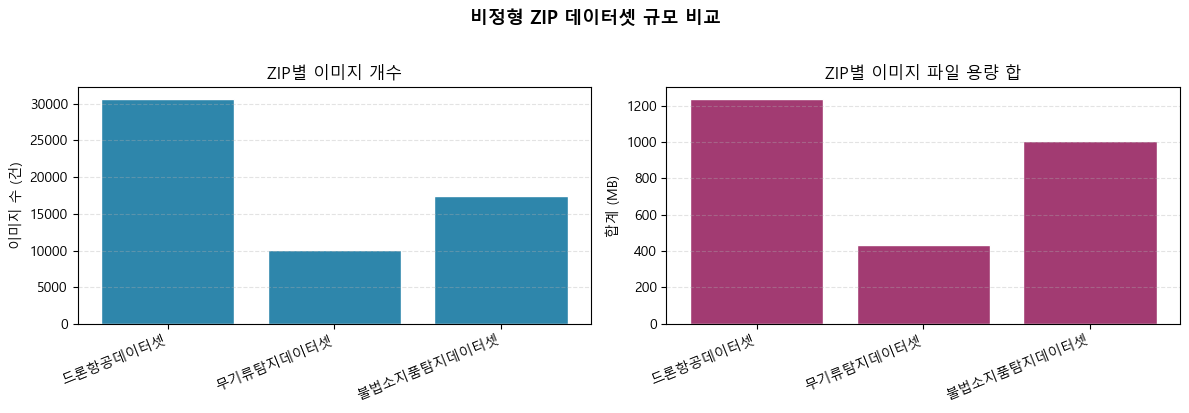

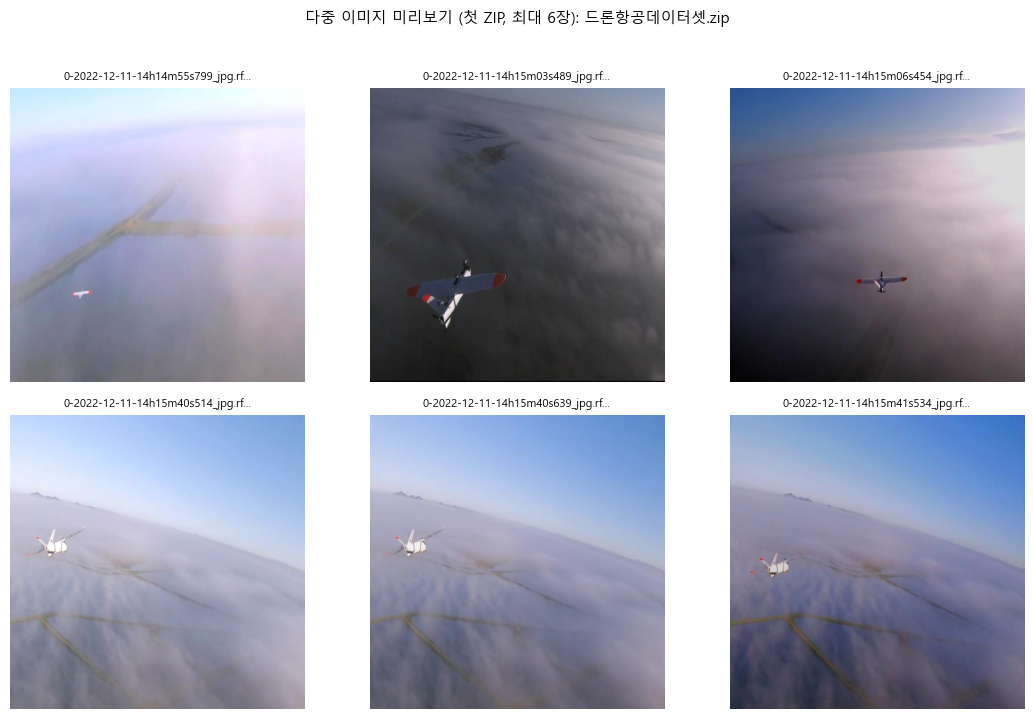

In [8]:
# ── Matplotlib ────────────────────────────────────────────────────
# 그래프·축·스타일

import numpy as np
from itertools import islice

# ---------- (A) 1행 2열: ZIP별 이미지 개수 vs 용량 ----------
if not df_img.empty:
    summary_plot = (
        df_img.groupby("zip_file", as_index=False)
        .agg(
            image_count=("member", "count"),
            total_mb=("size_bytes", lambda s: s.sum() / 1e6),
        )
    )
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    labels = [
        (name.replace(".zip", "")[:14] + "…") if len(name) > 16 else name.replace(".zip", "")
        for name in summary_plot["zip_file"]
    ]
    x = np.arange(len(summary_plot))
    axes[0].bar(x, summary_plot["image_count"], color="#2e86ab", edgecolor="white")
    axes[0].set_xticks(x, labels, rotation=22, ha="right")
    axes[0].set_ylabel("이미지 수 (건)")
    axes[0].set_title("ZIP별 이미지 개수")
    axes[0].grid(axis="y", linestyle="--", alpha=0.35)

    axes[1].bar(x, summary_plot["total_mb"], color="#a23b72", edgecolor="white")
    axes[1].set_xticks(x, labels, rotation=22, ha="right")
    axes[1].set_ylabel("합계 (MB)")
    axes[1].set_title("ZIP별 이미지 파일 용량 합")
    axes[1].grid(axis="y", linestyle="--", alpha=0.35)

    fig.suptitle("비정형 ZIP 데이터셋 규모 비교", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("df_img가 비어 있어 막대 그래프를 생략합니다.")

# ---------- (B) 2×3 격자: 첫 ZIP에서 여러 장 동시 미리보기 ----------
NUM_GRID = 6
if zip_paths:
    zp0 = zip_paths[0]
    members = [m for m, _ in islice(iter_image_members(zp0), NUM_GRID)]
    if members:
        nrows, ncols = 2, 3
        fig2, axes2 = plt.subplots(nrows, ncols, figsize=(11, 7), squeeze=False)
        for i, (r, c) in enumerate(np.ndindex(nrows, ncols)):
            ax = axes2[r, c]
            if i < len(members):
                im = load_image_from_zip(zp0, members[i])
                ax.imshow(im)
                short = Path(members[i]).name
                ax.set_title(short[:32] + ("…" if len(short) > 32 else ""), fontsize=8)
            ax.axis("off")
        fig2.suptitle(
            f"다중 이미지 미리보기 (첫 ZIP, 최대 {len(members)}장): {zp0.name}",
            fontsize=11,
            y=1.02,
        )
        plt.tight_layout()
        plt.show()


## 6. (선택) 특정 폴더만 필터링

Roboflow/YOLO 형식은 보통 `train/images`, `valid/images` 등에 이미지가 있습니다.  
필요하면 `member` 문자열로 필터링해 수집 범위를 줄일 수 있습니다.

In [9]:
# ── 함수 정의 ─────────────────────────────────────────────────────────
# 재사용 가능한 블록

def collect_images_under(zip_path: Path, path_contains: str = "images/") -> list[str]:
    """ZIP 내 경로에 `path_contains`가 포함된 이미지 멤버만 반환."""
    out: list[str] = []
    with zipfile.ZipFile(zip_path, mode="r") as zf:
        for info in zf.infolist():
            if info.is_dir():
                continue
            if path_contains not in info.filename.replace("\\", "/"):
                continue
            if Path(info.filename).suffix.lower() in IMAGE_SUFFIXES:
                out.append(info.filename)
    return out

# 예: 첫 번째 ZIP에서 images/ 아래만
if zip_paths:
    sample_zip = zip_paths[0]
    filtered = collect_images_under(sample_zip, "images/")
    print(sample_zip.name, "→ images/ 포함 이미지:", len(filtered), "개")
    print("예:", filtered[:2])


드론항공데이터셋.zip → images/ 포함 이미지: 30712 개
예: ['test/images/0-2022-12-11-14h14m55s799_jpg.rf.8b3448a85f4efd98076f73a66ccadcc6.jpg', 'test/images/0-2022-12-11-14h15m03s489_jpg.rf.90f718d25034f371b96a44f9e748a6cc.jpg']
